# Single-cell metabolic landscape of a head & neck tumour

scRNA-seq measures mRNA, not metabolites — but the transcriptome
carries a strong, recoverable signal of a cell's metabolic state.
This tutorial runs a complete metabolic analysis of a real tumour,
reproducing the landmark study **Xiao, Dai & Locasale, *Nat Commun*
2019 — "Metabolic landscape of the tumor microenvironment at single
cell resolution"** on its head & neck cancer cohort, with
`ov.single.Metabolism`.

## Part.1 The question and the approach

A tumour is an ecosystem — malignant cells, fibroblasts, endothelium
and immune cells share one microenvironment but run very different
metabolic programs. Bulk RNA-seq averages them away. Single-cell
resolution recovers, for **each cell**, the activity of every
metabolic pathway.

`ov.single.Metabolism` offers three paradigms behind one `method=`:
**scMetabolism** (pathway-activity scoring over KEGG/REACTOME),
**scFEA** (graph-neural-network metabolic-module flux) and
**Compass** (constraint-based reaction flux). This tutorial uses
scMetabolism for the landscape and scFEA for flux; the companion
tutorial covers metabolite cell-cell communication (MEBOCOST).

We will reproduce four findings from Xiao 2019:

1. malignant cells up-regulate the **most** metabolic pathways;
2. **oxidative phosphorylation** is the dominant axis of metabolic
   heterogeneity;
3. glycolysis and OXPHOS both **couple to hypoxia**;
4. each cell type runs a distinct metabolic program.

In [1]:
import omicverse as ov
import scanpy as sc

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Part.2 The HNSC tumour atlas

The Puram et al. 2017 head-and-neck squamous-cell-carcinoma atlas
(GSE103322) — 5,578 single cells from 19 patients, the very dataset
Xiao 2019 analysed. Expression is log2(TPM/10+1); each cell is
annotated as malignant or as a stromal / immune cell type.

In [2]:
adata = ov.datasets.metabolism_hnsc()
adata

🔍 Downloading data to ./data/hnsc_puram2017_full.h5ad
⚠️ File ./data/hnsc_puram2017_full.h5ad already exists


AnnData object with n_obs × n_vars = 5578 × 23686
    obs: 'patient', 'malignant', 'celltype', 'lymph_node', 'maxima_enzyme'
    uns: 'dataset', 'expression_units'

In [3]:
adata.obs['celltype'].value_counts()

celltype
Malignant      2215
Fibroblast     1440
T cell         1237
Endothelial     260
B cell          138
Mast            120
Macrophage       98
Dendritic        51
myocyte          19
Name: count, dtype: int64

## Part.3 Embedding

A standard embedding for visualisation — the data is already
log-normalised, so we select highly variable genes, scale, and run
PCA / neighbours / UMAP with `ov.pp`.

In [4]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata.raw = adata
hvg = adata[:, adata.var.highly_variable].copy()
ov.pp.scale(hvg)
ov.pp.pca(hvg, layer='scaled', n_pcs=30)


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.5232s                                                 │
│  Shape:    5,578 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ status                                               │
│           │ ✚ status_args                                          │
│                                                                    │
│  ● LAYERS │ ✚ scaled (array, 5578x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
compu

   🔧 PCA solver used: covariance_eigh
    finished✅ (3.55s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 3.5542s                                                 │
│  Shape:    5,578 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 5578x30)                               │
│           │ ✚ scaled|original|X_pca (array, 5578x30)               │
│         

In [5]:
ov.pp.neighbors(hvg, n_neighbors=15, n_pcs=30,
                use_rep='scaled|original|X_pca')
ov.pp.umap(hvg)
adata.obsm['X_umap'] = hvg.obsm['X_umap']

🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 15
   Method: umap
   Metric: euclidean
   Representation: scaled|original|X_pca
   PCs used: 30
   🔍 Computing neighbor distances...


   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 5,578 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 12.1651s                                                │
│  Shape:    5,578 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivit


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 5,578 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 1.3384s                                                 │
│  Shape:    5,578 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': 0.5830300199950147, 'b': 1.334166993228519}│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 5578x2)                               │
│                  

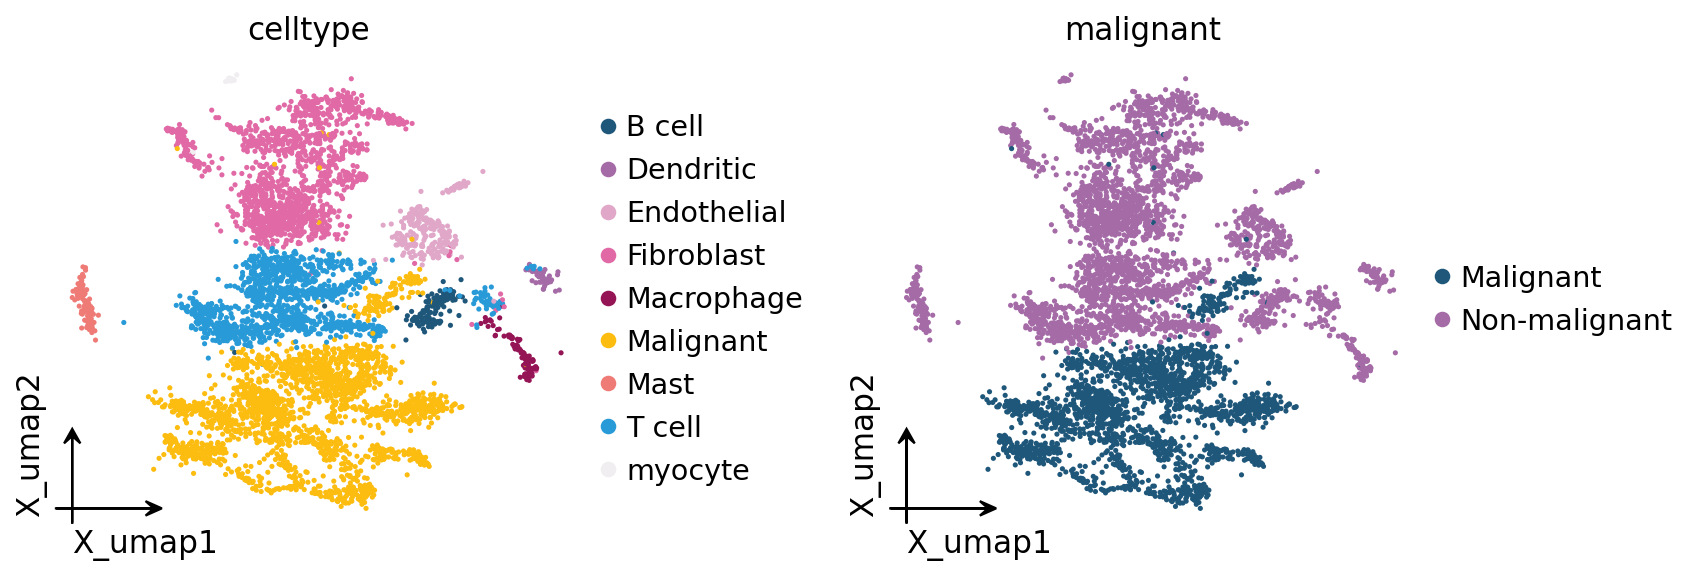

In [6]:
ov.pl.embedding(adata, basis='X_umap', color=['celltype', 'malignant'],
                frameon='small', wspace=0.5)

## Part.4 Score the metabolic landscape

`ov.single.Metabolism(method='scmetabolism')` scores all 85 KEGG
metabolic pathways for every cell with the AUCell enrichment scorer.
The result lands in `adata.obsm['X_metabolism']` — a 5,578 x 85
cell-by-pathway activity matrix.

In [7]:
met = ov.single.Metabolism(adata, method='scmetabolism')
met.run(score_method='AUCell', metabolism_type='KEGG')

In [8]:
adata.obsm['X_metabolism'].shape   # cells x KEGG metabolic pathways

(5578, 85)

## Part.5 Malignant cells are the most metabolically active

Xiao 2019's headline result: against the bulk-tumour view, single
cells reveal that **malignant cells up-regulate far more metabolic
pathways than any stromal or immune population**. We test it with
`ov.single.differential_metabolism` — a Mann-Whitney test of every
pathway's activity, malignant vs. non-malignant cells.

In [9]:
deg = ov.single.differential_metabolism(
    adata, groupby='malignant', group1='Malignant')
up = deg.query('padj < 0.05 and log2fc > 0')
print(f'{len(up)} of {len(deg)} KEGG pathways up-regulated in malignant cells')

53 of 85 KEGG pathways up-regulated in malignant cells


In [10]:
deg.head(8)   # the most malignant-skewed metabolic pathways

,feature,mean1,mean2,log2fc,statistic,pval,padj,direction
0,Glycolysis / Gluconeogenesis,0.148391,0.089109,0.735763,6778325.0,0.0,0.0,up
1,Pentose phosphate pathway,0.106197,0.056830,0.902011,5944860.0,0.0,0.0,up
2,Oxidative phosphorylation,0.230178,0.122040,0.915394,6899061.5,0.0,0.0,up
3,Folate biosynthesis,0.070516,0.025385,1.473938,6044921.0,0.0,0.0,up
4,Pyrimidine metabolism,0.057207,0.036858,0.634212,6047366.5,0.0,0.0,up
5,Cysteine and methionine metabolism,0.093844,0.057375,0.709856,6207366.0,0.0,0.0,up
6,Purine metabolism,0.054976,0.038136,0.527640,6223389.5,0.0,0.0,up
7,Phenylalanine metabolism,0.099794,0.044781,1.156077,6432450.0,0.0,0.0,up


How does that compare across the microenvironment? We count the
significantly up-regulated pathways for each cell type in turn.
Xiao 2019 found malignant cells far ahead of every stromal and
immune population — the metabolic activity of the tumour compartment
that bulk RNA-seq averages away.

In [11]:
import pandas as pd

n_up = {ct: len(ov.single.differential_metabolism(
            adata, groupby='celltype', group1=ct)
        .query('padj < 0.05 and log2fc > 0'))
        for ct in ['Malignant', 'Fibroblast', 'Macrophage', 'B cell', 'T cell']}
pd.Series(n_up).sort_values(ascending=False)

Malignant     53
Macrophage    38
Fibroblast    27
B cell        17
T cell        15
dtype: int64

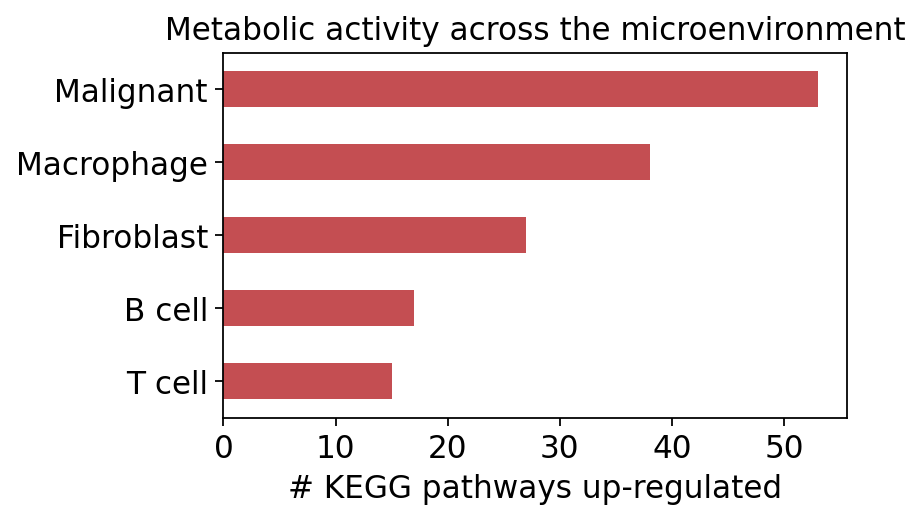

In [12]:
import matplotlib.pyplot as plt

ax = pd.Series(n_up).sort_values().plot.barh(color='#C44E52', figsize=(5, 3))
ax.set_xlabel('# KEGG pathways up-regulated')
ax.set_title('Metabolic activity across the microenvironment')
plt.show()

## Part.6 Metabolic heterogeneity within the tumour

Xiao 2019 highlighted mitochondrial / oxidative-phosphorylation
programs as a major source of **intratumoural** metabolic
heterogeneity — even within one compartment, cells differ in energy
metabolism. Projected onto the UMAP, OXPHOS activity is far from
uniform across the tumour:

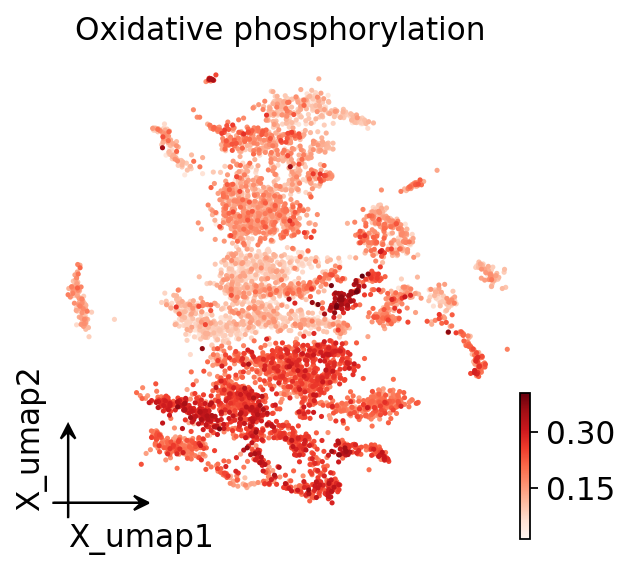

In [13]:
met.to_obs('Oxidative phosphorylation')
ov.pl.embedding(adata, basis='X_umap', color='Oxidative phosphorylation',
                cmap='Reds', frameon='small')

Resolved by cell type, OXPHOS varies both **between** cell types and
**within** them — the spread inside the malignant violin is
intratumoural metabolic heterogeneity:

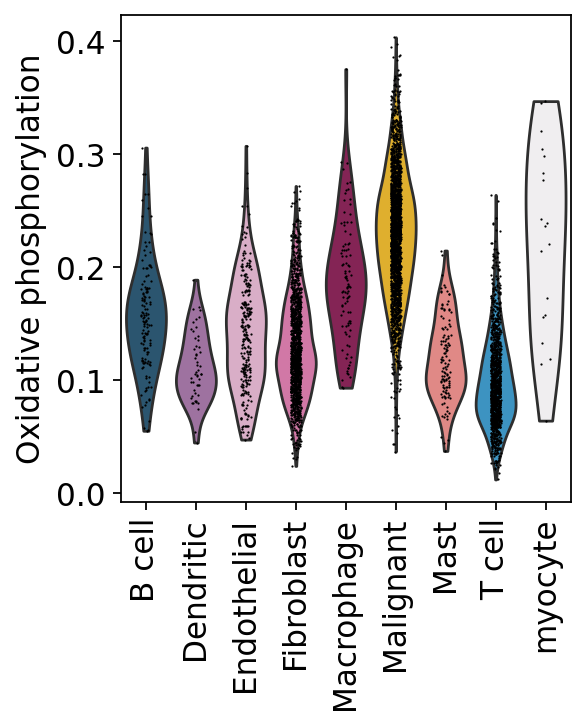

In [14]:
sc.pl.violin(adata, keys='Oxidative phosphorylation',
             groupby='celltype', rotation=90)

## Part.7 Glycolysis and OXPHOS couple to hypoxia

A counter-intuitive Xiao 2019 result: in the tumour, the glycolytic
and the mitochondrial programs are **not** anti-correlated — both
rise together with hypoxia. We score each cell for the HALLMARK
hypoxia signature and correlate it with the two energy pathways.

In [15]:
sigs = ov.utils.geneset_prepare(
    ov.utils.predefined_signatures['hallmark'], organism='Human')
sc.tl.score_genes(adata, sigs['HALLMARK_HYPOXIA'], score_name='hypoxia')

       'ERO1A', 'CAVIN3', 'CCN5', 'LARGE1', 'NOCT', 'CAVIN1', 'CCN1', 'CCN2',
       'ACKR3'],
      dtype='object')


In [16]:
scores = met.get()
energy = pd.DataFrame({
    'hypoxia': adata.obs['hypoxia'].to_numpy(),
    'Glycolysis': scores['Glycolysis / Gluconeogenesis'].to_numpy(),
    'OXPHOS': scores['Oxidative phosphorylation'].to_numpy()})
energy.corr().round(2)

,hypoxia,Glycolysis,OXPHOS
hypoxia,1.00,0.50,0.22
Glycolysis,0.50,1.00,0.62
OXPHOS,0.22,0.62,1.00


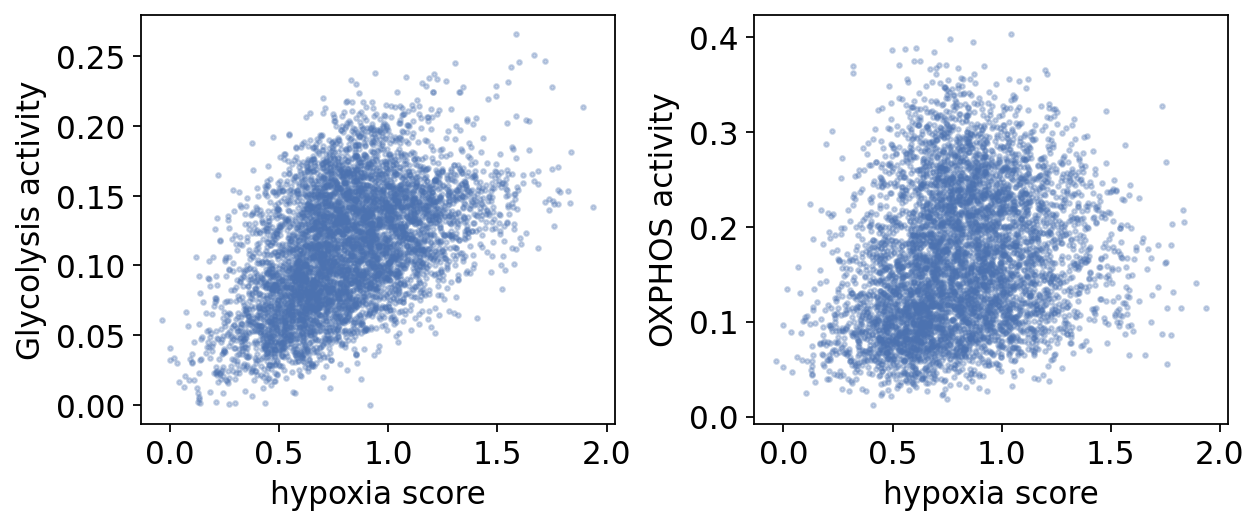

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, col in zip(axes, ['Glycolysis', 'OXPHOS']):
    ax.scatter(energy['hypoxia'], energy[col], s=4, alpha=0.3, color='#4C72B0')
    ax.set(xlabel='hypoxia score', ylabel=f'{col} activity')
plt.tight_layout(); plt.show()

## Part.8 Cell-type-specific metabolic programs

Beyond the malignant compartment, each microenvironment cell type
runs its own metabolic program — `ov.pl.metabolism_heatmap` averages
pathway activity within each cell type and keeps the most
discriminating, non-redundant pathways.

<Axes: title={'center': 'scmetabolism — metabolic features by celltype'}, xlabel='celltype'>

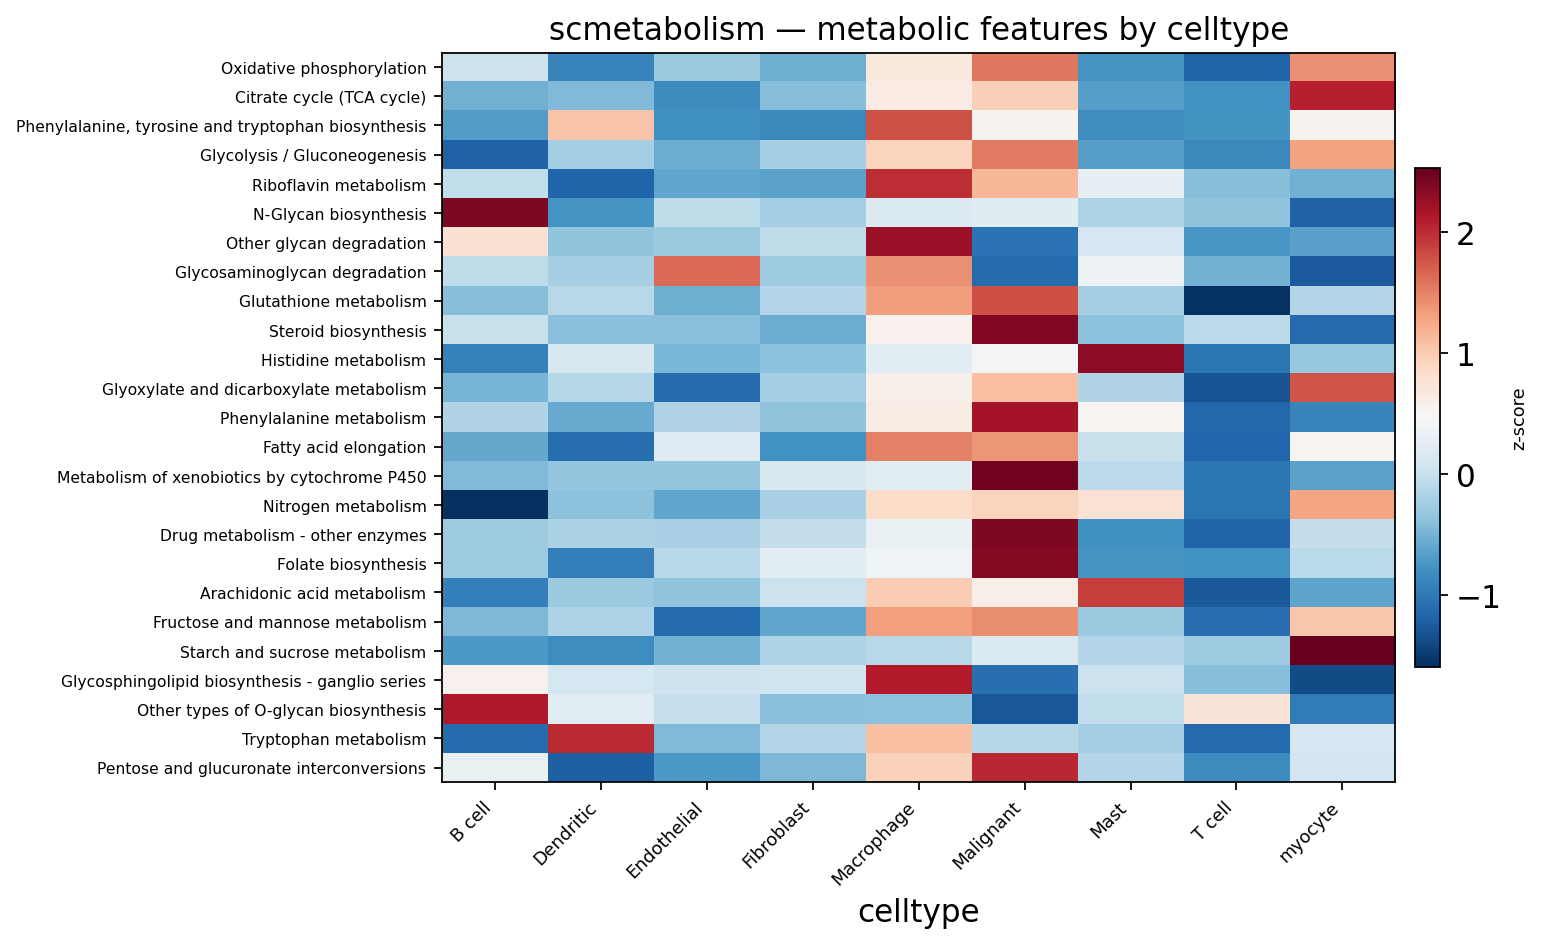

In [18]:
ov.pl.metabolism_heatmap(adata, groupby='celltype', n_features=25)

## Part.9 Metabolic flux with scFEA

Pathway *activity* reads gene expression; metabolic *flux* asks how
fast each reaction actually runs. scFEA estimates flux through ~168
metabolic modules with a graph neural network constrained by
metabolite mass-balance. Flux estimation is heavier than scoring, so
we run it on a 400-cell subsample as a complementary view.

In [19]:
sub = sc.pp.subsample(adata, n_obs=400, random_state=0, copy=True)
flux = ov.single.Metabolism(sub, method='scfea')
flux.run(n_epoch=25, verbose=False)

<Axes: title={'center': 'scfea — metabolic features by celltype'}, xlabel='celltype'>

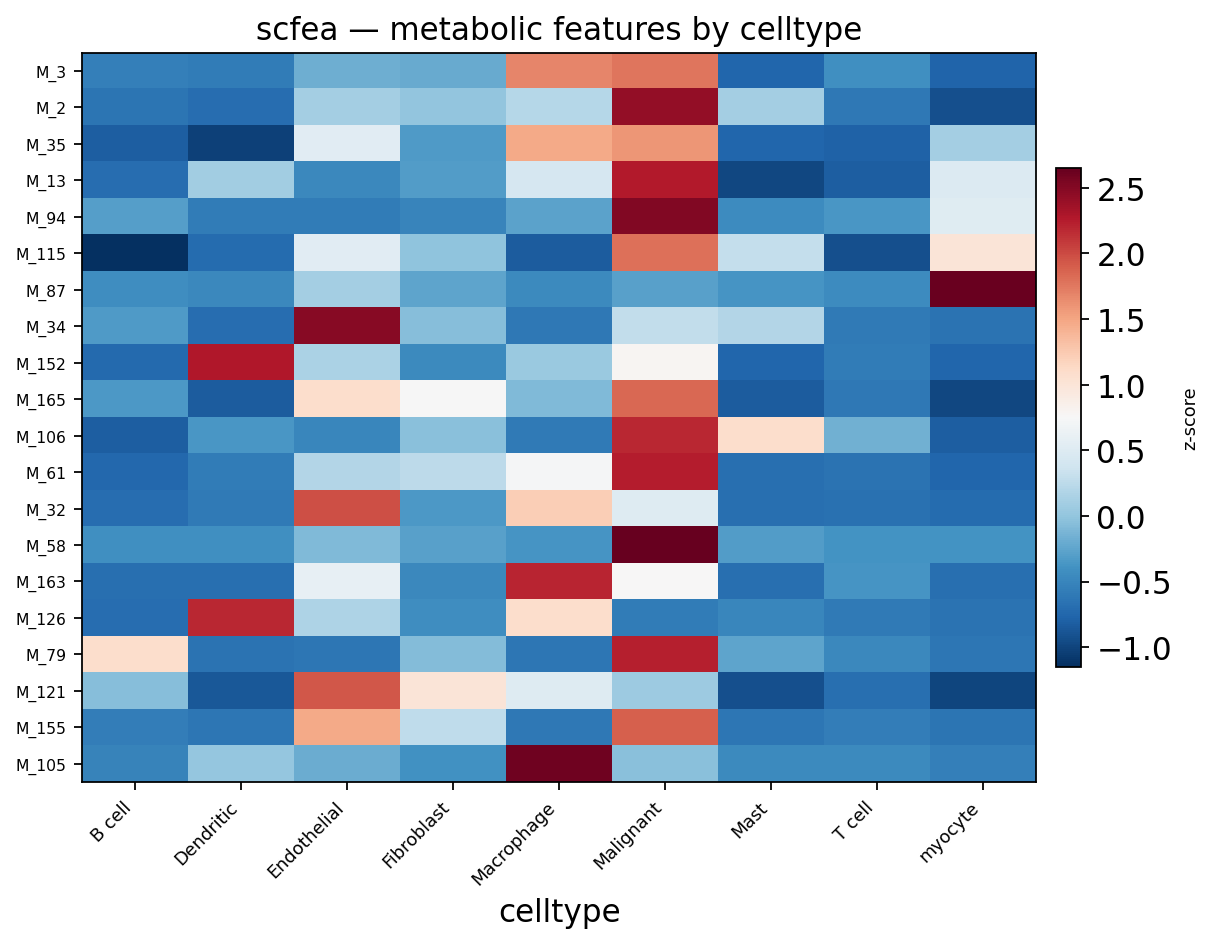

In [20]:
ov.pl.metabolism_heatmap(sub, groupby='celltype', n_features=20)

---

## Recap — a metabolic landscape, reproduced

Running `ov.single.Metabolism` on the Puram 2017 HNSC atlas recovers
the core conclusions of Xiao et al. 2019:

| finding | this analysis |
|---|---|
| malignant cells up-regulate the most metabolic pathways | counted with `differential_metabolism`; malignant ranks first |
| OXPHOS heterogeneity within the tumour | the OXPHOS UMAP + per-cell-type violin |
| glycolysis & OXPHOS couple to hypoxia | both positively correlate with the HALLMARK hypoxia score |
| cell types run distinct programs | the cell-type x pathway heatmap |

The third paradigm, **Compass** constraint-based reaction flux, is
available as `ov.single.Metabolism(method='compass')` — it needs a
commercial LP solver and is run offline. For metabolite-mediated
cell-cell communication in this same tumour, see the companion
tutorial **Metabolite cell-cell communication with MEBOCOST**.